# 01 — Data Loading and Feature Engineering

**Project:** Statistical Arbitrage via Clustering on US Energy Equities  
**Stage:** Data acquisition + feature computation  
**Output:** Clean prices, log returns, and per-stock features saved to `../data/`

## What this notebook does

1. Defines our 22-stock energy universe across 6 sub-industries
2. Downloads daily adjusted closing prices from Yahoo Finance (2014-06-01 to today)
3. Cleans the data (handles missing values, drops bad tickers)
4. Computes daily log returns
5. Engineers per-stock features for clustering (volatility, beta, skewness, etc.)
6. Saves everything to `../data/` for use by the next notebook

## Why these choices

- **Start date 2014-06-01:** captures four distinct regimes (2014-16 oil crash, 2017-19 calm, 2020 COVID, 2022-26 geopolitical crises) → rich variation for testing whether clustering adapts
- **End date today:** maximum currentness, includes active Iran crisis
- **Adjusted close prices:** account for splits and dividends so returns reflect actual investor experience

## 1. Setup and Universe Definition

In [3]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Make sure data directory exists
os.makedirs('../data', exist_ok=True)

print(f'Notebook run on: {datetime.now().strftime("%Y-%m-%d %H:%M")}')

Notebook run on: 2026-05-06 22:28


In [5]:
# Our 22-stock universe across 6 sub-industries
# Each ticker mapped to its sub-industry — this is our 'economic ground truth' that we'll later compare clustering results against.

ENERGY_UNIVERSE = {
    # Integrated majors (3) — diversified across upstream, refining, chemicals
    'XOM':  'integrated_major',
    'CVX':  'integrated_major',
    'COP':  'integrated_major',

    # Upstream / E&P (6) — pure-play producers, most levered to oil prices
    'EOG':  'upstream',
    'OXY':  'upstream',
    'DVN':  'upstream',
    'FANG': 'upstream',
    'AR':   'upstream_gas',   # natural gas focused
    'EQT':  'upstream_gas',   # natural gas focused

    # Refiners (4) — convert crude to products, profit on crack spreads
    'VLO':  'refiner',
    'MPC':  'refiner',
    'PSX':  'refiner',
    'DINO': 'refiner',

    # Midstream / pipelines (5) — fee-based toll roads, less commodity-sensitive
    'KMI':  'midstream',
    'WMB':  'midstream',
    'OKE':  'midstream',
    'EPD':  'midstream',
    'ET':   'midstream',

    # Oilfield services (4) — drilling and well services, cyclical with capex
    'SLB':  'services',
    'HAL':  'services',
    'BKR':  'services',
    'NOV':  'services',
}

# Reference instruments for factor regression (NOT traded as pairs)
FACTORS = {
    'XLE':  'sector_etf',   # Energy Select Sector SPDR — sector factor
    'SPY':  'market_etf',   # S&P 500 ETF — broad market factor
}

# Combined list for downloading
ALL_TICKERS = list(ENERGY_UNIVERSE.keys()) + list(FACTORS.keys())

# Date range
START_DATE = '2014-06-01'
END_DATE = datetime.now().strftime('%Y-%m-%d')

print(f'Universe: {len(ENERGY_UNIVERSE)} energy stocks + {len(FACTORS)} factor ETFs = {len(ALL_TICKERS)} total')
print(f'Date range: {START_DATE} to {END_DATE}')
print(f'\nSub-industry breakdown:')
for industry in sorted(set(ENERGY_UNIVERSE.values())):
    tickers = [t for t, i in ENERGY_UNIVERSE.items() if i == industry]
    print(f'  {industry:20s} ({len(tickers)}): {", ".join(tickers)}')

Universe: 22 energy stocks + 2 factor ETFs = 24 total
Date range: 2014-06-01 to 2026-05-06

Sub-industry breakdown:
  integrated_major     (3): XOM, CVX, COP
  midstream            (5): KMI, WMB, OKE, EPD, ET
  refiner              (4): VLO, MPC, PSX, DINO
  services             (4): SLB, HAL, BKR, NOV
  upstream             (4): EOG, OXY, DVN, FANG
  upstream_gas         (2): AR, EQT


## 2. Download Price Data

Pulling from Yahoo Finance via `yfinance`. We use `auto_adjust=True` so prices reflect splits and dividends (the proper basis for return computation).

In [6]:
# Download all tickers in one call (faster than ticker-by-ticker)
raw_data = yf.download(
    tickers=ALL_TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=True,
)

# Extract closing prices (already split- and dividend-adjusted because auto_adjust=True)
prices = raw_data['Close'].copy()

print(f'\nDownloaded prices: {prices.shape[0]} trading days × {prices.shape[1]} tickers')
print(f'First date: {prices.index[0].date()}')
print(f'Last date: {prices.index[-1].date()}')

[*********************100%***********************]  24 of 24 completed


Downloaded prices: 3000 trading days × 24 tickers
First date: 2014-06-02
Last date: 2026-05-05


## 3. Data Quality Check

Check for missing data. Drop tickers with poor coverage (less than 80% of days). This catches tickers that may have IPO'd later or have data issues.

In [7]:
# Coverage = fraction of days with valid prices
coverage = prices.notna().mean().sort_values()

print('Data coverage by ticker (sorted ascending):')
for ticker, cov in coverage.items():
    flag = '⚠️ ' if cov < 0.95 else '   '
    print(f'  {flag}{ticker:6s} {cov:.1%}')

Data coverage by ticker (sorted ascending):
     AR     100.0%
     WMB    100.0%
     VLO    100.0%
     SPY    100.0%
     SLB    100.0%
     PSX    100.0%
     OXY    100.0%
     OKE    100.0%
     NOV    100.0%
     MPC    100.0%
     KMI    100.0%
     HAL    100.0%
     FANG   100.0%
     ET     100.0%
     EQT    100.0%
     EPD    100.0%
     EOG    100.0%
     DVN    100.0%
     DINO   100.0%
     CVX    100.0%
     COP    100.0%
     BKR    100.0%
     XLE    100.0%
     XOM    100.0%


In [8]:
# Drop any ticker with less than 80% coverage
MIN_COVERAGE = 0.80
valid_tickers = coverage[coverage >= MIN_COVERAGE].index.tolist()
dropped = set(prices.columns) - set(valid_tickers)

if dropped:
    print(f'\nDropping tickers with <{MIN_COVERAGE:.0%} coverage: {dropped}')
else:
    print(f'\nAll tickers passed the {MIN_COVERAGE:.0%} coverage threshold.')

prices = prices[valid_tickers]

# Forward-fill remaining gaps (e.g., a stock missing for 1-2 days mid-history)
# Only forward-fill, never backfill — we don't want to leak future info into the past.
prices = prices.ffill()

# Drop the first few rows that may have remaining NaN (before earliest ticker existed)
prices = prices.dropna()

print(f'\nFinal clean prices shape: {prices.shape}')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')
prices.head()


All tickers passed the 80% coverage threshold.

Final clean prices shape: (3000, 24)
Date range: 2014-06-02 to 2026-05-05


Ticker,AR,WMB,VLO,SPY,SLB,PSX,OXY,OKE,NOV,MPC,...,EQT,EPD,EOG,DVN,DINO,CVX,COP,BKR,XLE,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2014-06-02,61.810001,24.232260,36.232105,157.378311,75.221771,55.789913,66.854591,31.132242,61.354786,31.523436,...,52.419384,16.860336,75.530884,49.379417,32.270073,74.153099,54.257160,37.173817,30.094561,61.070583
2014-06-03,63.049999,24.185772,35.520409,157.296677,75.178322,55.331734,67.176262,31.141903,62.868210,30.950716,...,52.897549,16.802467,76.448296,50.056206,31.688337,74.359383,54.489277,37.126427,30.198885,61.345551
2014-06-04,64.059998,24.227093,34.975426,157.614868,75.084221,54.781948,67.122650,31.368895,63.108021,30.862881,...,53.037014,16.793573,76.240448,50.170124,31.523836,74.238014,54.475616,37.005314,30.183077,61.131672
2014-06-05,63.520000,24.475044,35.674294,158.642838,75.221771,54.664139,67.618561,31.658680,63.058399,30.883953,...,53.076870,16.784668,77.337059,50.116524,31.629114,74.947975,54.646290,37.331783,30.356985,61.443333
2014-06-06,63.430000,24.655846,35.405022,159.401566,76.727509,55.213940,67.753571,31.822887,63.794430,30.810183,...,52.992180,16.742386,78.354858,50.036106,31.392231,75.354485,55.185574,37.910980,30.606735,62.084949


## 4. Visual Sanity Check

Plot normalized prices for a few representative tickers across sub-industries. This is a quick sanity check that the data looks right and lets us visually identify regime shifts.

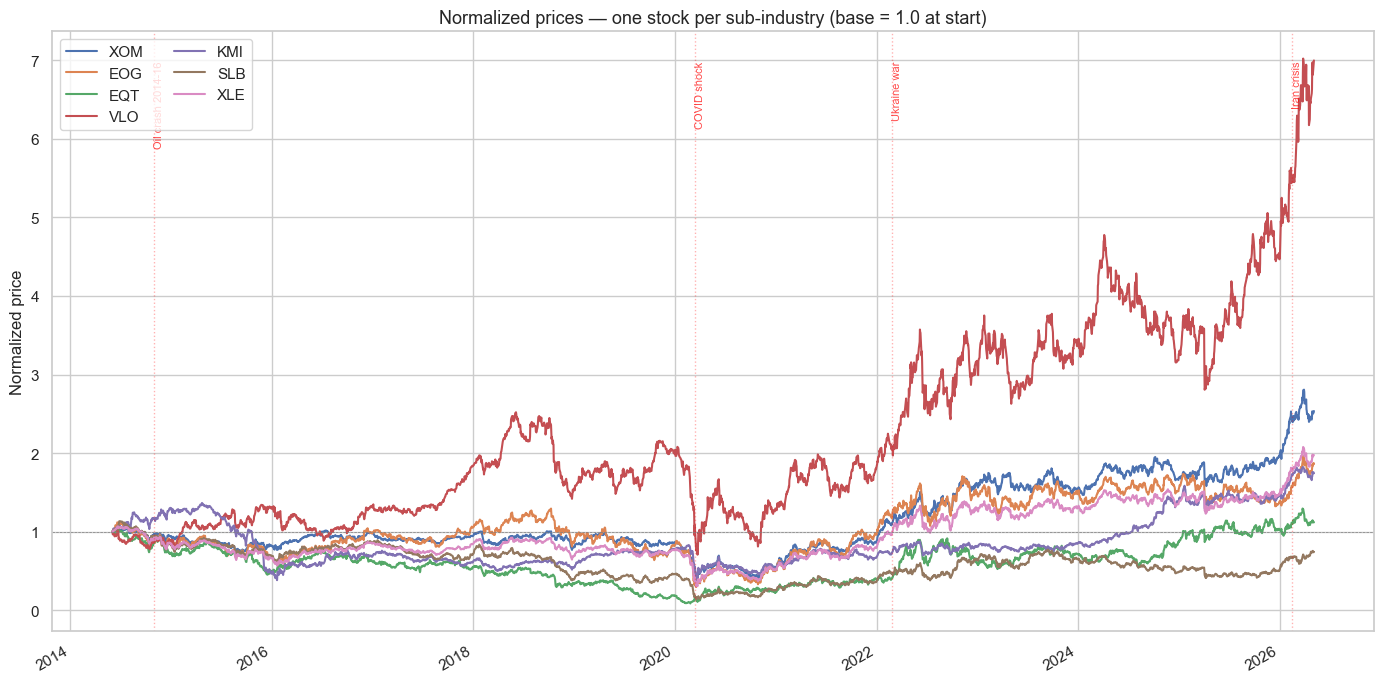

In [9]:
# Normalize prices to start at 1.0 for easy comparison
norm_prices = prices / prices.iloc[0]

# Pick one representative from each sub-industry
representatives = ['XOM', 'EOG', 'EQT', 'VLO', 'KMI', 'SLB', 'XLE']
available = [t for t in representatives if t in norm_prices.columns]

fig, ax = plt.subplots(figsize=(14, 7))
norm_prices[available].plot(ax=ax, linewidth=1.5)
ax.set_title('Normalized prices — one stock per sub-industry (base = 1.0 at start)', fontsize=13)
ax.set_ylabel('Normalized price')
ax.set_xlabel('')
ax.axhline(1.0, color='gray', linewidth=0.5, linestyle='--')

# Mark the major regime breaks for visual reference
regime_dates = {
    'Oil crash 2014-16': '2014-11-01',
    'COVID shock': '2020-03-15',
    'Ukraine war': '2022-02-24',
    'Iran crisis': '2026-02-15',
}
for label, date in regime_dates.items():
    if pd.Timestamp(date) >= norm_prices.index[0] and pd.Timestamp(date) <= norm_prices.index[-1]:
        ax.axvline(pd.Timestamp(date), color='red', alpha=0.3, linewidth=1, linestyle=':')
        ax.text(pd.Timestamp(date), ax.get_ylim()[1]*0.95, label, rotation=90,
                fontsize=8, color='red', alpha=0.7, va='top')

ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

## 5. Compute Log Returns

We use **log returns** rather than simple percentage returns because:
- They're additive over time (log return over N days = sum of N daily log returns)
- They're approximately normal for small moves
- Standard in financial econometrics

$r_t = \log(P_t / P_{t-1})$

In [10]:
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f'Log returns shape: {log_returns.shape}')
print(f'Sample stats (annualized):')
print(f'  Mean returns: {(log_returns.mean() * 252).describe()[["mean", "min", "max"]].round(3).to_dict()}')
print(f'  Volatilities: {(log_returns.std() * np.sqrt(252)).describe()[["mean", "min", "max"]].round(3).to_dict()}')

Log returns shape: (2999, 24)
Sample stats (annualized):
  Mean returns: {'mean': 0.055, 'min': -0.094, 'max': 0.177}
  Volatilities: {'mean': 0.391, 'min': 0.175, 'max': 0.581}


## 6. Engineer Per-Stock Features for Clustering

This is the core feature engineering step. For each stock, we compute a vector of summary statistics from its return history. These features will be the input to K-means clustering.

**Why these features?** They capture the dimensions along which energy stocks meaningfully differ:

| Feature | What it captures |
|---|---|
| Mean return (annualized) | Long-run drift |
| Volatility (annualized) | Risk level |
| Skewness | Asymmetry of return distribution |
| Kurtosis | Fat-tailedness (crisis exposure) |
| Beta to XLE | Sensitivity to energy sector |
| Beta to SPY | Sensitivity to broad market |
| Idiosyncratic vol | Volatility unexplained by sector + market |
| Autocorrelation lag-1 | Momentum / mean-reversion tendency |
| Max drawdown | Worst peak-to-trough loss |

**Important:** we compute features only on the **formation period** (pre-2020) to avoid leakage of crisis-era information into the clustering. NEED TO REVIEW WHY FOR THIS MORE!!!!!

In [11]:
# Split into formation (in-sample for clustering) and test (out-of-sample for backtesting)
FORMATION_END = '2019-12-31'

formation_returns = log_returns[log_returns.index <= FORMATION_END]
test_returns = log_returns[log_returns.index > FORMATION_END]

print(f'Formation period: {formation_returns.index[0].date()} to {formation_returns.index[-1].date()} ({len(formation_returns)} days)')
print(f'Test period:      {test_returns.index[0].date()} to {test_returns.index[-1].date()} ({len(test_returns)} days)')

Formation period: 2014-06-03 to 2019-12-31 (1406 days)
Test period:      2020-01-02 to 2026-05-05 (1593 days)


In [13]:
def compute_stock_features(returns, sector_returns, market_returns):
    """Compute per-stock features for clustering.
    
    Each row of the returned DataFrame is one stock.
    Each column is a feature.
    """
    features = pd.DataFrame(index=returns.columns)
    
    # Basic distribution features (annualized where appropriate)
    features['mean_return']  = returns.mean() * 252
    features['volatility']   = returns.std() * np.sqrt(252)
    features['skewness']     = returns.skew()
    features['kurtosis']     = returns.kurt()
    
    # Autocorrelation: tendency for returns to follow themselves (momentum vs mean-reversion)
    features['autocorr_1d']  = returns.apply(lambda s: s.autocorr(lag=1))
    
    # Max drawdown over the period
    cum_returns = (1 + returns).cumprod()
    rolling_max = cum_returns.cummax()
    drawdown = (cum_returns - rolling_max) / rolling_max
    features['max_drawdown'] = drawdown.min()
    
    # Beta and idiosyncratic volatility from factor regression
    # r_stock = alpha + beta_sector * r_XLE + beta_market * r_SPY + epsilon
    sector_aligned = sector_returns.reindex(returns.index)
    market_aligned = market_returns.reindex(returns.index)
    
    betas_sector = []
    betas_market = []
    idio_vols = []
    
    for ticker in returns.columns:
        y = returns[ticker].dropna()
        X = pd.DataFrame({
            'XLE': sector_aligned.loc[y.index],
            'SPY': market_aligned.loc[y.index],
        })
        # Add intercept
        X = pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)
        # OLS via numpy
        coefs, residuals, _, _ = np.linalg.lstsq(X.values, y.values, rcond=None)
        betas_sector.append(coefs[1])
        betas_market.append(coefs[2])
        # Idiosyncratic vol = std of residuals from this regression
        fitted = X.values @ coefs
        resid = y.values - fitted
        idio_vols.append(np.std(resid) * np.sqrt(252))
    
    features['beta_sector']  = betas_sector
    features['beta_market']  = betas_market
    features['idio_vol']     = idio_vols
    
    return features

# Compute features only on formation period — no leakage from crisis era
energy_tickers = list(ENERGY_UNIVERSE.keys())
energy_tickers = [t for t in energy_tickers if t in formation_returns.columns]

stock_features = compute_stock_features(
    returns=formation_returns[energy_tickers],
    sector_returns=formation_returns['XLE'],
    market_returns=formation_returns['SPY'],
)

# Add the ground-truth sub-industry label (won't be used for clustering, but for validation later)
stock_features['sub_industry'] = stock_features.index.map(ENERGY_UNIVERSE)

print(f'Feature matrix shape: {stock_features.shape}')
stock_features.round(3)

Feature matrix shape: (22, 10)


,mean_return,volatility,skewness,kurtosis,autocorr_1d,max_drawdown,beta_sector,beta_market,idio_vol,sub_industry
Ticker,,,,,,,,,,
XOM,-0.027,0.189,-0.132,2.494,0.002,-0.330,0.669,0.182,0.101,integrated_major
CVX,0.037,0.219,-0.047,2.155,0.016,-0.470,0.864,0.061,0.109,integrated_major
COP,-0.008,0.310,0.032,2.370,-0.010,-0.644,1.331,-0.229,0.163,integrated_major
EOG,-0.033,0.317,0.034,1.725,-0.017,-0.563,1.430,-0.350,0.160,upstream
OXY,-0.104,0.253,-0.225,1.935,-0.034,-0.603,1.000,-0.107,0.151,upstream
DVN,-0.173,0.428,0.080,2.589,-0.023,-0.837,1.854,-0.438,0.235,upstream
FANG,0.038,0.387,-0.384,3.182,-0.019,-0.517,1.479,-0.320,0.259,upstream
AR,-0.551,0.475,0.229,2.623,-0.015,-0.984,1.509,-0.528,0.386,upstream_gas
EQT,-0.294,0.386,-0.107,2.529,-0.040,-0.904,0.989,0.012,0.323,upstream_gas


## 7. Quick Visualization of Features

Plot the feature distributions colored by sub-industry. If our features are meaningful, we should already see some natural separation between sub-industries.

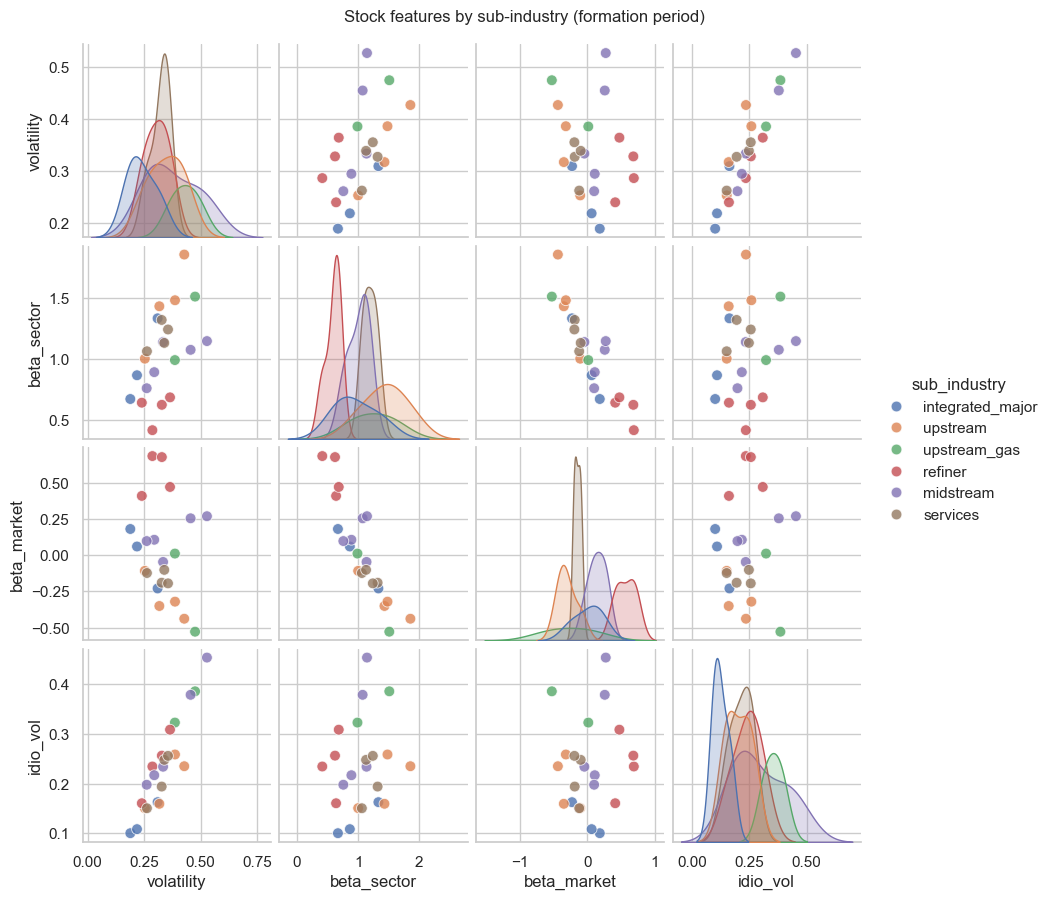

In [14]:
feature_cols = [c for c in stock_features.columns if c != 'sub_industry']

# Pairplot of the most interpretable features, colored by sub-industry
key_features = ['volatility', 'beta_sector', 'beta_market', 'idio_vol']
pp_data = stock_features[key_features + ['sub_industry']].copy()

g = sns.pairplot(pp_data, hue='sub_industry', height=2.2, plot_kws={'s': 60, 'alpha': 0.8})
g.fig.suptitle('Stock features by sub-industry (formation period)', y=1.02, fontsize=12)
plt.show()

Look at this plot carefully. We're hoping to see:
- **Midstream** stocks (KMI, WMB, etc.) clustering with low volatility and low beta
- **Upstream** stocks (EOG, OXY, etc.) clustering with higher volatility and higher sector beta
- **Refiners** (VLO, MPC, etc.) somewhere in between, possibly with distinctive idio vol
- **Services** (SLB, HAL, etc.) showing high cyclicality (high volatility, high beta)

COME BACK TO THESE THGOUHTS + ASSUMPTIONS, NEED TO REVIEW WHY THEY AREN'T CORRECT. WE DO SEE SEPERATION THO WHICH IS GOOD, AND HOW ARE THESE GRAPHS CREATED WHAT THE HELLY?

If we already see partial separation here, K-means in standardized feature space should find clean clusters.

## 8. Save Outputs

Save everything to `../data/` for the next notebook (`02_clustering_and_pairs.ipynb`) to load.

In [15]:
prices.to_csv('../data/prices.csv')
log_returns.to_csv('../data/log_returns.csv')
stock_features.to_csv('../data/stock_features.csv')

# Save universe mapping as JSON-friendly CSV for reproducibility
universe_df = pd.DataFrame([
    {'ticker': t, 'sub_industry': i, 'role': 'energy'} for t, i in ENERGY_UNIVERSE.items()
] + [
    {'ticker': t, 'sub_industry': i, 'role': 'factor'} for t, i in FACTORS.items()
])
universe_df.to_csv('../data/universe.csv', index=False)

print('Saved files:')
for f in ['prices.csv', 'log_returns.csv', 'stock_features.csv', 'universe.csv']:
    path = f'../data/{f}'
    size_kb = os.path.getsize(path) / 1024
    print(f'  {path:35s} ({size_kb:.0f} KB)')

Saved files:
  ../data/prices.csv                  (1319 KB)
  ../data/log_returns.csv             (1528 KB)
  ../data/stock_features.csv          (4 KB)
  ../data/universe.csv                (1 KB)


## Summary

We have:

- **`prices.csv`** — daily adjusted closing prices, all 22 stocks + 2 factor ETFs
- **`log_returns.csv`** — daily log returns
- **`stock_features.csv`** — per-stock features (vol, beta, skew, etc.) computed on formation period
- **`universe.csv`** — ticker → sub-industry mapping

All ready for the next notebook, where we'll standardize features, apply PCA for visualization, and run K-means clustering.

## Decisions Made (Worth Defending in Q&A)

| Decision | Reasoning |
|---|---|
| 22 stocks across 6 sub-industries | Heterogeneous enough for clustering to find structure, small enough to inspect manually |
| Start 2014-06-01 | Captures four major regime shifts (2014 crash, COVID, Ukraine, Iran) |
| Auto-adjusted prices | Account for splits and dividends |
| Log returns | Additive across time, standard in econometrics |
| Formation period 2014-2019 | Train clustering only on pre-COVID data — no leakage from crisis era |
| Drop tickers <80% coverage | Avoids contamination from late IPOs or data issues |
| Forward-fill only | Never backfill — would leak future into past |
